In [4]:
from matplotlib import pyplot as pl
import math
import numpy as np
import sigmf
import scipy

## Load a tx signal

In [16]:
DATA_ROOT = 'data'
#tx_filename = 'zadoff-chu-fs250000-fzc25000-l55001-q89-2.2sec-1x.sigmf-data'
tx_filename = 'zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x.sigmf-data'

In [17]:
tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx-2025-06-21/{tx_filename}"
tx_sigmf_file = sigmf.sigmffile.fromfile(tx_sigmf_filename)
tx_info = tx_sigmf_file.get_global_info()
display(tx_info)
sample_rate = tx_info['core:sample_rate'] #/ au.s
tx_samples = tx_sigmf_file.read_samples().astype("complex64")
print(len(tx_samples))

{'core:author': 'Thomas Telkamp',
 'core:datatype': 'ci16_le',
 'core:description': 'zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x',
 'core:sample_rate': 250000.0,
 'core:sha512': '2e4adbed7dd0da271676cef54e3021f5f5a9d836e2b50ca8f4621db88be7673a019398dc1c2476e1b57d7b78181cffc8d99d0dbc08e27e60972e43b9f16c102c',
 'core:version': '1.2.5',
 'vrt:tx_gain': 10,
 'core:num_channels': 1}

15000000


## Explore the tx signal

In [20]:
if 0:
    #%matplotlib widget
    pl.figure()
    pl.plot(tx_samples)

In [25]:
if 0:
    pl.psd(tx_samples, Fs=sample_rate, NFFT=2**16);
    pl.title('TX Power Spectral Density')

In [22]:
if 0: # Debug: tx spectrogram
    Sxx_tx, f_tx, t_tx, image_tx = pl.specgram(tx_samples, Fs=sample_rate, NFFT=2**8)
    pl.title('TX Spectrogram')
    pl.gca().set_xlabel("Time (s)")
    pl.gca().set_ylabel("Frequency from center (Hz)")

## Regenerate the Zadoff Chu sequence

In [49]:
def gen_zadoff_chu(n, u, q=0):
  """
  Generates a Zadoff-Chu sequence.
 
  Parameters:
  - n (int): length of the sequence, usually prime
  - u (int): root index of the sequence
  - q (int, optional): cyclic shift
  
  Returns:
  - np.array: The complex Zadoff-Chu sequence
  """ 
  assert n > 0
  assert u > 0 and u < n, f"{u=} must be between 0 and {n=}"
  assert math.gcd(n, u) == 1, f"{n=} and {u=} must be coprime"
  cf = n % 2  # Conjugate flag depending on whether n is even or odd.
  v = np.arange(n)
  return np.exp(-1j * np.pi * u * v * (v + cf + 2 * q) / n)

In [14]:
# Camras file name format:
# tx_filename = 'zadoff-chu-fs250000-fzc25000-l55001-q89-2.2sec-1x.sigmf-data'
fs = 250000    # sample rate of final signal
fzc = 25000    # sample rate of the ZC sequence: it is trivially upsampled to fs by repeating sample values fs / fzc times (why not smoothed?)
l = 55001      # length of the ZC sequence (we call this "n")
q = 89         # root index of the ZC sequence (we call this "u")
# cyclic index of the ZC sequence is 0 (this is our default value for "q")
duration = 2.2 # 2.2sec: duration of the signal
rep = 1        # 1x: repetitions of the signal

## tx_filename = 'zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x.sigmf-data'
#fs = 250000     # sample rate of final signal
#fzc = 50000     # sample rate of the ZC sequence: it is trivially upsampled to fs by repeating sample values fs / fzc times (why not smoothed?)
#l = 3000017     # length of the ZC sequence (we call this "n")
#q = 2411        # root index of the ZC sequence (we call this "u")
## cyclic index of the ZC sequence is 0 (this is our default value for "q")
#duration = 60.0 # sec: duration of the signal
#rep = 1         # 1x: repetitions of the signal

# To recreate the signal in the tx_filename given above, we use:
zc = gen_zadoff_chu(l, q)
# Then trivially upsample by repeating samples. Note: Thomas uses int(duration * fs / int(duration * fzc)), which technically could be different?
zc_fs = np.repeat(zc, int(fs / fzc))
# Then repeat: for example, data = np.tile(data,repeats)
# Then truncate to the specified duration
print(len(zc_fs), int(duration * fs))
zc_fst = zc_fs[:int(duration * fs)]

550010 550000


In [45]:
if 0: # Plot waveform...
  #%matplotlib widget
  pl.figure()
  pl.plot(zc)
  pl.show()

In [47]:
if 0: # Plot PSD
   pl.psd(zc, Fs=fs, NFFT=2**16) 

In [48]:
if 0: # Compare my regenerated signal with the camras signal.
    #%matplotlib widget
    #pl.figure()
    pl.plot(zc_fst[:1000])
    pl.plot(tx_samples[:1000], '.')
    pl.title("Comparison of tx_signal and regenerated zc_fst signal")
    pl.show()

In [50]:
import re

def gen_zadoff_chu_matching_camras(filename):
    assert filename.startswith("zadoff-chu")
    fs, fzc, l, q, duration, repeats = [eval(x) for x in re.findall(r"\d+\.*\d*", filename)]
    print(filename)
    display({"fs": fs, "fzc": fzc, "l": l, "q": q, "duration": duration, "repeats": repeats})
    # Generate the 'raw' Zadoff-Chu sequence
    zc = gen_zadoff_chu(l, q)
    # Then upsample by repeating samples. Note: Thomas uses int(duration * fs / int(duration * fzc)), which technically could be different?
    zc_fs = np.repeat(zc, int(fs / fzc))
    # Then repeat
    zc_fsr = np.tile(zc_fs, repeats)
    # Then truncate to the specified duration
    zc_fsrt = zc_fsr[:int(duration * fs)]
    return zc_fsrt

zc_fsrt = gen_zadoff_chu_matching_camras("zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x.sigmf-data")

zadoff-chu-fs250000-fzc50000-l3000017-q2411-60sec-1x.sigmf-data


{'fs': 250000,
 'fzc': 50000,
 'l': 3000017,
 'q': 2411,
 'duration': 60,
 'repeats': 1}

## Explore the Constant Amplitude Zero Autocorrelation (CAZAC) property

(3000016.999999999-2.0456091552589047e-10j)


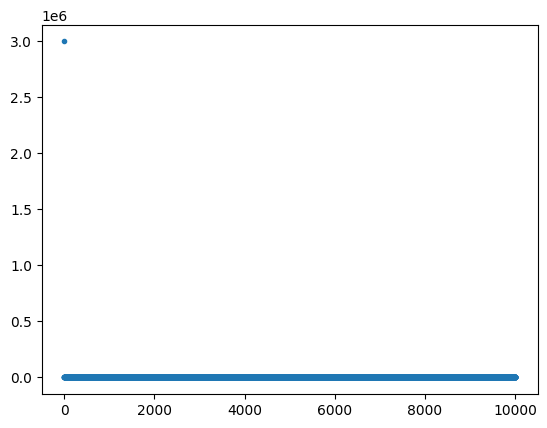

In [41]:
# Autocorrelate the simple ZC signal
ac = scipy.signal.correlate(zc, zc, mode='same')
ac = ac[ac.size//2:]
pl.plot(ac[:10000], '.')
print(ac.max())
# Note that the autocorrelation isn't strictly zero.

(15000000.000000004-6.322740266720454e-10j)


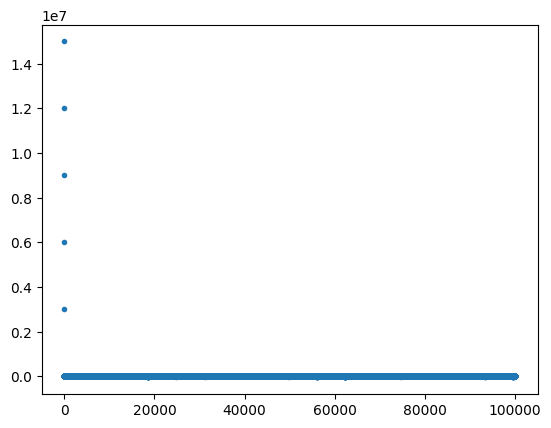

In [40]:
# Autocorrelate the repeat-upsampled signal
#ac = scipy.signal.correlate(tx_samples, tx_samples, mode='same')
#ac = ac[ac.size//2:]
#pl.plot(ac[:100000], '.')

ac = scipy.signal.correlate(zc_fst, zc_fst, mode='same')
ac = ac[ac.size//2:]
pl.plot(ac[:100000], '.')
print(ac.max())
# Note that due to the repeat upsampling, peaks are spread by 10 samples.

(14999999.81062351+1.4933571219444277e-11j)


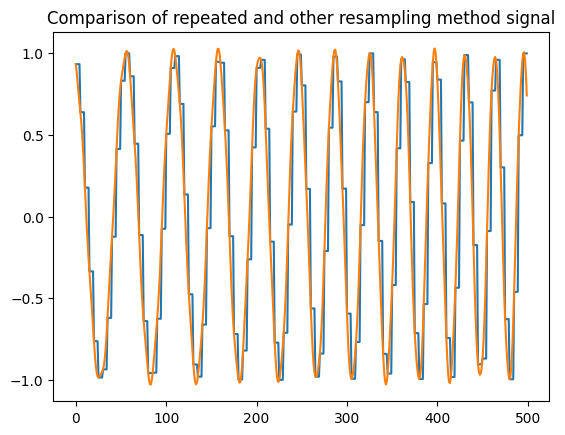

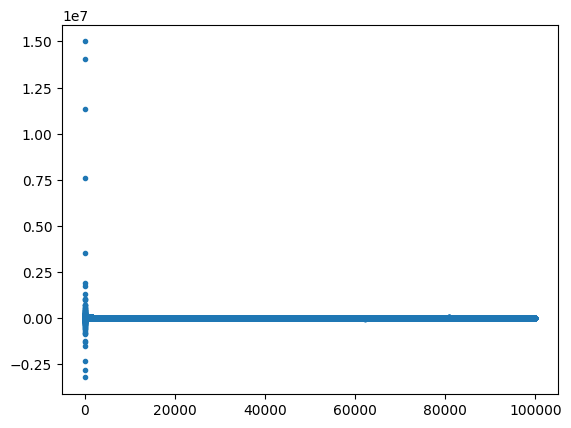

In [46]:
# Experiment with more sophisticated upsampling
import scipy.signal

#zc_fs2 = np.interp(np.arange(0, len(zc), 0.1), np.arange(0, len(zc), 1), zc)
# Note that 'interp' (linear interpolation):
# 1. *Deceases* the autocorrelation peak.
# 2. Spreads the peak over ~20 samples

zc_fs2 = scipy.signal.resample(zc, l * int(fs / fzc))
# Note that 'resample':
# 1. Doesn't change the autocorrelation peak
# 2. Doesn't reduce the peak spread
# 3. Introduces anti-peaks
# 4. Can exceed the range [-1, 1]

#zc_fs2 = scipy.signal.resample_poly(zc, l * int(fs / fzc), 1)  # Can't run: too much memory!

zc_fst2 = zc_fs2[:int(duration) * fs]

pl.plot(zc_fst[500:1000])
pl.plot(zc_fst2[500:1000])
pl.title("Comparison of repeated and other resampling method signal")

ac = scipy.signal.correlate(zc_fst2, zc_fst2, mode='same')
ac = ac[ac.size//2:]
pl.figure()
pl.plot(ac[:100000], '.')
print(ac.max())